# Lamar River 7-Day Streamflow Forecasting (Stage 3b - SNOTEL + Probabilistic)

**Combines Stage 3 SNOTEL Features with Probabilistic Quantile Regression**

## Objective
Enhance the Stage 3 model by adding probabilistic quantile regression [P10, P50, P90] outputs while keeping the simple LSTM architecture.

## Stage 3b Enhancements
1. **SNOTEL Integration**: Add Snow Water Equivalent (SWE) data
   - Stations: Parker Peak (683) and Northeast Entrance (670)
   - Explicitly provides the "tank level" (storage state)
2. **Probabilistic Forecasts**: Quantile regression [P10, P50, P90]
3. **Simple LSTM Architecture**: Same as Stage 3, but outputs 3 quantiles per timestep

## The "Storage Problem" Solved

**Scenario**: Late June, temperatures hit 80°F.
- **Without SWE**: Model thinks "High temps = High melt" → Predicts peak
- **Reality**: Snowpack melted out last week → River drops
- **With SWE + Uncertainty**: Model sees SWE=0 inches → Correctly predicts low flow with uncertainty bounds

## Data Sources
- **Streamflow**: USGS 06191500 (Lamar River near Tower Falls, WY)
- **Climate**: gridMET (4km resolution, 3 elevation bands)
- **Snow**: SNOTEL Stations 683 & 670 (SWE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

Using device: cuda
GPU: NVIDIA GeForce GTX 1070


## 1. Quantile Loss Function

Pinball loss for probabilistic forecasting with asymmetric penalties.

In [2]:
class QuantileLoss(nn.Module):
    """Pinball loss for quantile regression.
    
    For quantile q:
    - If actual > predicted: loss = q * (actual - predicted)
    - If actual < predicted: loss = (1-q) * (predicted - actual)
    
    This asymmetric penalty ensures proper quantile coverage.
    """
    def __init__(self, quantiles=[0.1, 0.5, 0.9]):
        super(QuantileLoss, self).__init__()
        self.quantiles = quantiles
        
    def forward(self, preds, target):
        losses = []
        
        for i, q in enumerate(self.quantiles):
            pred_q = preds[:, :, i]
            errors = target - pred_q
            loss_q = torch.max(q * errors, (q - 1) * errors)
            losses.append(loss_q.mean())
        
        return sum(losses) / len(losses)


print("Quantile loss function loaded:")
print("  - Produces [P10, P50, P90] uncertainty bounds")
print("  - Asymmetric penalties for proper calibration")
print("\n✓ Ready for probabilistic forecasting!")

Quantile loss function loaded:
  - Produces [P10, P50, P90] uncertainty bounds
  - Asymmetric penalties for proper calibration

✓ Ready for probabilistic forecasting!


## 2. Data Loading

Load streamflow, climate, and SNOTEL data.

In [3]:
# Load streamflow data
df_flow = pd.read_csv('../data/lamar_river_streamflow.csv')
df_flow['date'] = pd.to_datetime(df_flow['date'])

if df_flow['date'].dt.tz is not None:
    df_flow['date'] = df_flow['date'].dt.tz_localize(None)

df_flow = df_flow.sort_values('date').reset_index(drop=True)

# Filter to dates >= 1998-01-01 for consistency with climate data
df_flow = df_flow[df_flow['date'] >= '1998-01-01'].copy()
df_flow = df_flow.reset_index(drop=True)

print(f"Streamflow data loaded: {len(df_flow):,} records")
print(f"Date range: {df_flow['date'].min()} to {df_flow['date'].max()}")

# Load climate data
climate_file = '../data/climate/lamar_gridmet_elevation_bands.csv'

try:
    df_climate = pd.read_csv(climate_file)
    df_climate['date'] = pd.to_datetime(df_climate['date'])
    print(f"\nClimate data loaded: {len(df_climate):,} records")
    print(f"Date range: {df_climate['date'].min()} to {df_climate['date'].max()}")
    climate_available = True
except FileNotFoundError:
    print(f"\n⚠ Climate data not found. Creating synthetic data for demo...")
    df_climate = df_flow[['date']].copy()
    df_climate['doy'] = df_climate['date'].dt.dayofyear
    
    for band in ['valley', 'mid', 'alpine']:
        df_climate[f'precip_{band}'] = 2.0 + 3.0 * np.sin(2 * np.pi * (df_climate['doy'] - 80) / 365) + np.random.normal(0, 1, len(df_climate))
        df_climate[f'precip_{band}'] = df_climate[f'precip_{band}'].clip(0)
    
    base_temp = 10 * np.sin(2 * np.pi * (df_climate['doy'] - 80) / 365)
    df_climate['temp_valley'] = base_temp + 5 + np.random.normal(0, 2, len(df_climate))
    df_climate['temp_mid'] = base_temp + 0 + np.random.normal(0, 2, len(df_climate))
    df_climate['temp_alpine'] = base_temp - 5 + np.random.normal(0, 2, len(df_climate))
    
    df_climate = df_climate.drop('doy', axis=1)
    climate_available = False

# Load SNOTEL data
snotel_file = '../data/snotel/lamar_snotel_combined.csv'

try:
    df_snotel = pd.read_csv(snotel_file)
    df_snotel['date'] = pd.to_datetime(df_snotel['date'])
    print(f"\nSNOTEL data loaded: {len(df_snotel):,} records")
    print(f"Date range: {df_snotel['date'].min()} to {df_snotel['date'].max()}")
    print(f"Columns: {list(df_snotel.columns)}")
    snotel_available = True
except FileNotFoundError:
    print(f"\n⚠ SNOTEL data not found at: {snotel_file}")
    print("Creating synthetic SWE data for demonstration...")
    
    df_snotel = df_flow[['date']].copy()
    df_snotel['doy'] = df_snotel['date'].dt.dayofyear
    
    swe_pattern = np.zeros(len(df_snotel))
    for i, doy in enumerate(df_snotel['doy']):
        if doy < 120:
            swe_pattern[i] = 20 * (doy / 120) + np.random.normal(0, 2)
        elif doy < 180:
            swe_pattern[i] = 20 * (1 - (doy - 120) / 60) + np.random.normal(0, 1)
        else:
            swe_pattern[i] = np.random.normal(0, 0.2)
    
    swe_pattern = np.clip(swe_pattern, 0, None)
    
    df_snotel['swe_parker_peak'] = swe_pattern
    df_snotel['swe_northeast_entrance'] = swe_pattern * 0.8
    df_snotel = df_snotel.drop('doy', axis=1)
    snotel_available = False

# Merge all datasets
df = pd.merge(df_flow, df_climate, on='date', how='inner')
df = pd.merge(df, df_snotel, on='date', how='inner')
df = df.sort_values('date').reset_index(drop=True)

print(f"\nMerged dataset: {len(df):,} records")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"✓ Data filtered to 1998+ for consistency")
print(f"\nAll columns: {list(df.columns)}")

Streamflow data loaded: 10,063 records
Date range: 1998-01-01 00:00:00 to 2025-11-20 00:00:00

Climate data loaded: 9,863 records
Date range: 1998-01-01 00:00:00 to 2025-01-01 00:00:00

SNOTEL data loaded: 9,919 records
Date range: 1998-10-01 00:00:00 to 2025-11-26 00:00:00
Columns: ['date', 'swe_northeast_entrance', 'swe_parker_peak']

Merged dataset: 9,552 records
Date range: 1998-10-01 00:00:00 to 2024-11-24 00:00:00
✓ Data filtered to 1998+ for consistency

All columns: ['date', 'streamflow_cfs', 'streamflow', 'precip_valley', 'temp_valley', 'precip_mid', 'temp_mid', 'precip_alpine', 'temp_alpine', 'swe_northeast_entrance', 'swe_parker_peak']


## 3. SWE Visualization

Visualize the seasonal pattern of snow accumulation and melt.

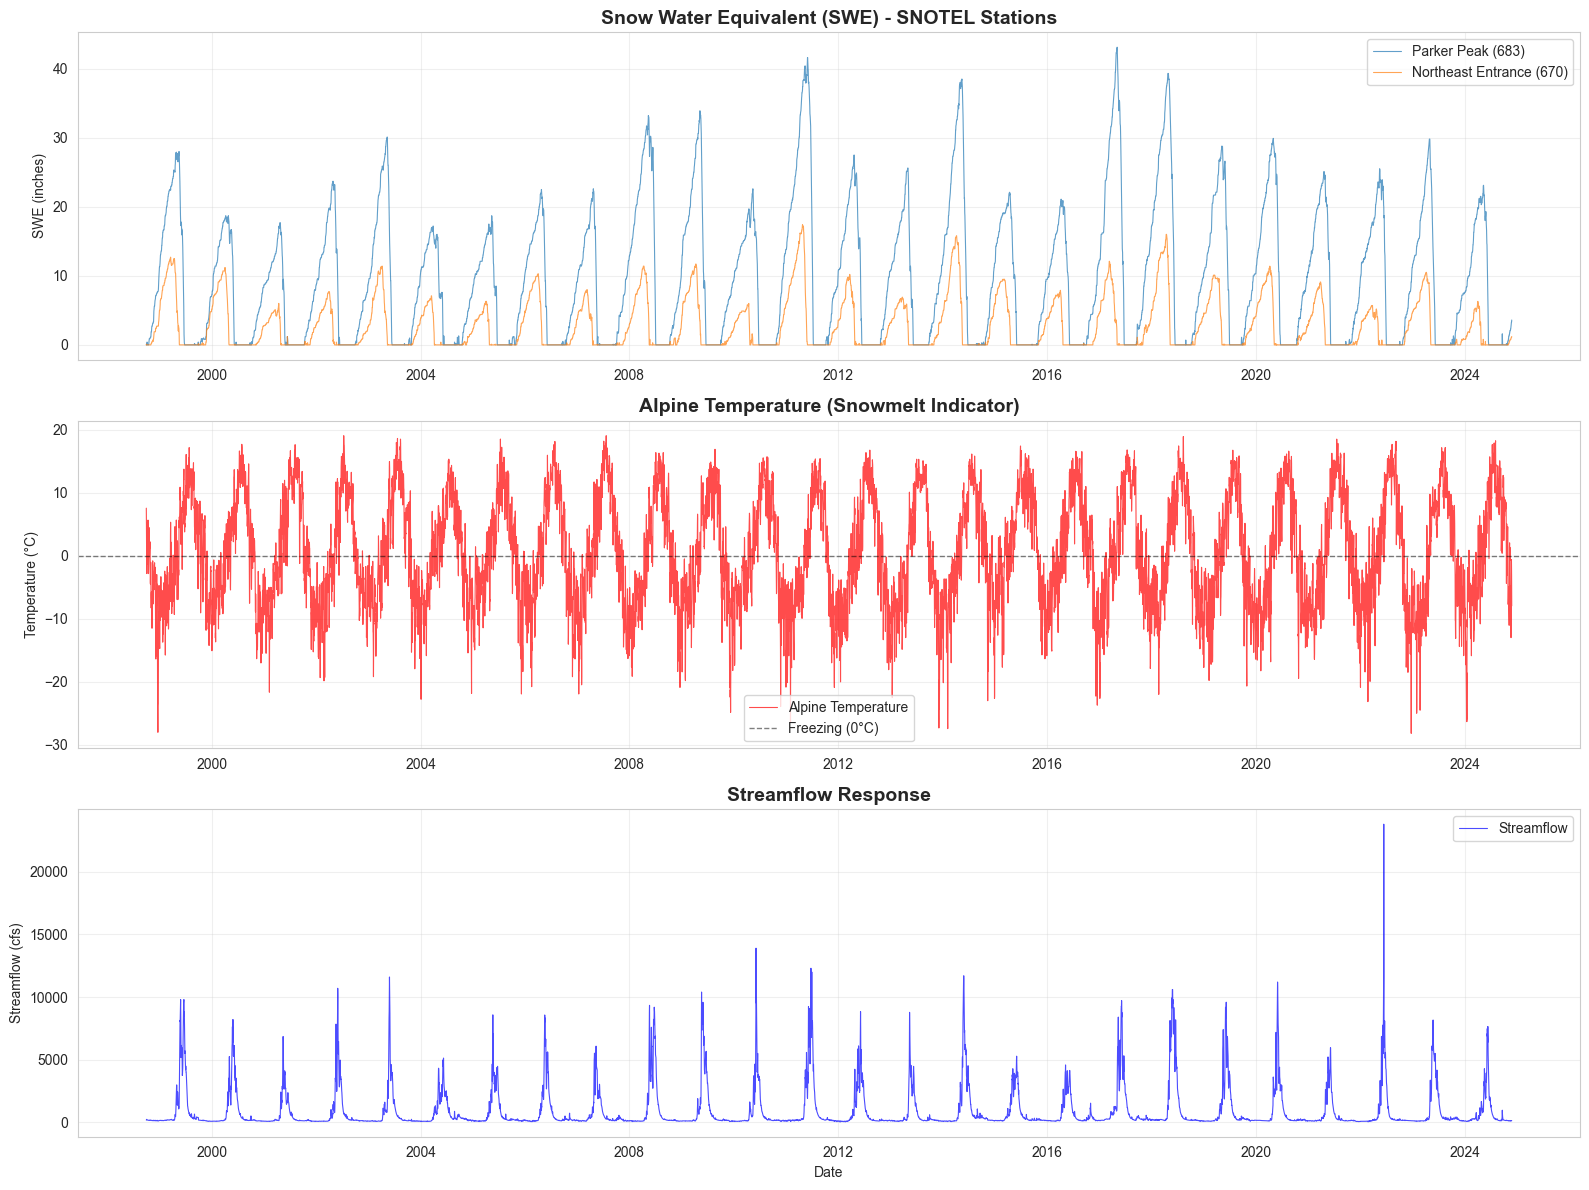


✓ SWE data shows clear seasonal pattern:
  - Accumulation: October - April
  - Peak: Late April / Early May
  - Melt: May - June
  - Zero: July - September

✓ This 'storage state' is critical for predicting snowmelt runoff!


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. SWE by station
axes[0].plot(df['date'], df['swe_parker_peak'], label='Parker Peak (683)', alpha=0.7, linewidth=0.8)
axes[0].plot(df['date'], df['swe_northeast_entrance'], label='Northeast Entrance (670)', alpha=0.7, linewidth=0.8)
axes[0].set_title('Snow Water Equivalent (SWE) - SNOTEL Stations', fontweight='bold', fontsize=14)
axes[0].set_ylabel('SWE (inches)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Temperature (Alpine)
axes[1].plot(df['date'], df['temp_alpine'], label='Alpine Temperature', alpha=0.7, linewidth=0.8, color='red')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Freezing (0°C)')
axes[1].set_title('Alpine Temperature (Snowmelt Indicator)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Streamflow
axes[2].plot(df['date'], df['streamflow_cfs'], label='Streamflow', alpha=0.7, linewidth=0.8, color='blue')
axes[2].set_title('Streamflow Response', fontweight='bold', fontsize=14)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Streamflow (cfs)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ SWE data shows clear seasonal pattern:")
print("  - Accumulation: October - April")
print("  - Peak: Late April / Early May")
print("  - Melt: May - June")
print("  - Zero: July - September")
print("\n✓ This 'storage state' is critical for predicting snowmelt runoff!")

## 4. Feature Engineering (Stage 3b)

### Stage 3b Feature Set:
1. Flow (log-transformed, scaled)
2. Sin(day of year)
3. Cos(day of year)
4-9. Climate: 3 bands × (precip + temp)
10-11. **SNOTEL**: SWE from 2 stations

In [5]:
# Add cyclical time features
df['doy'] = df['date'].dt.dayofyear
df['sin_doy'] = np.sin(2 * np.pi * df['doy'] / 365)
df['cos_doy'] = np.cos(2 * np.pi * df['doy'] / 365)

# Log-transform streamflow
df['flow_log'] = np.log(df['streamflow_cfs'] + 1)

print("Stage 3b Feature Engineering:")
print("  1. Flow: log(Q + 1)")
print("  2-3. Seasonality: sin/cos(doy)")
print("  4-9. Climate: 3 bands × (precip + temp)")
print("  10-11. **SWE: 2 SNOTEL stations**")
print(f"\nTotal features: 11")
print(f"\nSample data:")
print(df[['date', 'streamflow_cfs', 'flow_log', 'temp_alpine', 
          'swe_parker_peak']].head(10))

Stage 3b Feature Engineering:
  1. Flow: log(Q + 1)
  2-3. Seasonality: sin/cos(doy)
  4-9. Climate: 3 bands × (precip + temp)
  10-11. **SWE: 2 SNOTEL stations**

Total features: 11

Sample data:
        date  streamflow_cfs  flow_log  temp_alpine  swe_parker_peak
0 1998-10-01           183.0  5.214936     7.541667              0.0
1 1998-10-02           195.0  5.278115     4.808333              0.0
2 1998-10-03           218.0  5.389072    -0.416667              0.0
3 1998-10-04           239.0  5.480639    -2.625000              0.2
4 1998-10-05           219.0  5.393628    -2.841667              0.2
5 1998-10-06           199.0  5.298317     1.000000              0.4
6 1998-10-07           197.0  5.288267     5.025000              0.4
7 1998-10-08           193.0  5.267858     5.200000              0.1
8 1998-10-09           187.0  5.236442     2.766667              0.0
9 1998-10-10           181.0  5.204007     1.283333              0.0


## 5. Train/Test Split

In [6]:
# Train/Validation/Test Split (70/15/15)
train_size = int(0.70 * len(df))
val_size = int(0.15 * len(df))

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

print(f"Training set: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"  Records: {len(train_df):,} days ({len(train_df)/365.25:.1f} years)")
print(f"\nValidation set: {val_df['date'].min()} to {val_df['date'].max()}")
print(f"  Records: {len(val_df):,} days ({len(val_df)/365.25:.1f} years)")
print(f"\nTest set: {test_df['date'].min()} to {test_df['date'].max()}")
print(f"  Records: {len(test_df):,} days ({len(test_df)/365.25:.1f} years)")
print(f"\n✓ Chronological split (70/15/15) preserves temporal order")

Training set: 1998-10-01 00:00:00 to 2017-01-19 00:00:00
  Records: 6,686 days (18.3 years)

Validation set: 2017-01-20 00:00:00 to 2020-12-21 00:00:00
  Records: 1,432 days (3.9 years)

Test set: 2020-12-22 00:00:00 to 2024-11-24 00:00:00
  Records: 1,434 days (3.9 years)

✓ Chronological split (70/15/15) preserves temporal order


## 6. Feature Scaling

In [7]:
scalers = {}

# Flow scaler
scalers['flow'] = MinMaxScaler(feature_range=(0, 1))
train_df['flow_scaled'] = scalers['flow'].fit_transform(train_df[['flow_log']])
test_df['flow_scaled'] = scalers['flow'].transform(test_df[['flow_log']])
val_df['flow_scaled'] = scalers['flow'].transform(val_df[['flow_log']])

# Climate scalers
climate_features = []
for band in ['valley', 'mid', 'alpine']:
    # Precipitation
    precip_col = f'precip_{band}'
    scaled_col = f'precip_{band}_scaled'
    scalers[precip_col] = MinMaxScaler(feature_range=(0, 1))
    train_df[scaled_col] = scalers[precip_col].fit_transform(train_df[[precip_col]])
    test_df[scaled_col] = scalers[precip_col].transform(test_df[[precip_col]])
    val_df[scaled_col] = scalers[precip_col].transform(val_df[[precip_col]])
    climate_features.append(scaled_col)
    
    # Temperature
    temp_col = f'temp_{band}'
    scaled_col = f'temp_{band}_scaled'
    scalers[temp_col] = MinMaxScaler(feature_range=(0, 1))
    train_df[scaled_col] = scalers[temp_col].fit_transform(train_df[[temp_col]])
    test_df[scaled_col] = scalers[temp_col].transform(test_df[[temp_col]])
    val_df[scaled_col] = scalers[temp_col].transform(val_df[[temp_col]])
    climate_features.append(scaled_col)

# SWE scalers
swe_features = []
for station in ['northeast_entrance', 'parker_peak']:
    swe_col = f'swe_{station}'
    scaled_col = f'swe_{station}_scaled'
    scalers[swe_col] = MinMaxScaler(feature_range=(0, 1))
    train_df[scaled_col] = scalers[swe_col].fit_transform(train_df[[swe_col]])
    test_df[scaled_col] = scalers[swe_col].transform(test_df[[swe_col]])
    val_df[scaled_col] = scalers[swe_col].transform(val_df[[swe_col]])
    swe_features.append(scaled_col)

print("Feature scaling complete:")
print(f"  Flow: [0, 1]")
print(f"  Seasonality: [-1, 1] (no scaling needed)")
print(f"  Climate features: [0, 1] ({len(climate_features)} features)")
print(f"  SWE features: [0, 1] ({len(swe_features)} features)")
print(f"\n✓ All scalers fit on training data only (no data leakage)")

Feature scaling complete:
  Flow: [0, 1]
  Seasonality: [-1, 1] (no scaling needed)
  Climate features: [0, 1] (6 features)
  SWE features: [0, 1] (2 features)

✓ All scalers fit on training data only (no data leakage)


## 7. Dataset Class (Simple LSTM with Probabilistic Output)

### Architecture:
- **History Input**: 60 days × (flow + seasonality + climate + SWE)
- **Future Forcing**: 7 days × climate features
- **Target**: 7 days of flow
- **Output**: 3 quantiles [P10, P50, P90] per timestep (simple vector output)

In [8]:
class SNOTELDataset(Dataset):
    """Stage 3b Dataset with SNOTEL SWE for Probabilistic Forecasting.
    
    Creates sequences with:
    - History Input (x_past): 60-day lookback with all features
    - Future Forcing (x_future): 7-day ahead climate (no SWE - changes slowly)
    - Target (y): 7-day ahead flow values
    """
    
    def __init__(self, df, climate_features, swe_features, lookback=60, horizon=7):
        self.lookback = lookback
        self.horizon = horizon
        
        # Extract features
        self.flow = df['flow_scaled'].values
        self.sin_doy = df['sin_doy'].values
        self.cos_doy = df['cos_doy'].values
        
        # Climate and SWE features
        self.climate_features = df[climate_features].values
        self.swe_features = df[swe_features].values
        
        self.n_samples = len(df) - lookback - horizon + 1
        
        if self.n_samples <= 0:
            raise ValueError(f"Not enough data: need at least {lookback + horizon} samples")
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        # 1. HISTORY INPUT: 60 days of [flow, sin, cos, climate, swe]
        flow_window = self.flow[idx:idx + self.lookback]
        sin_window = self.sin_doy[idx:idx + self.lookback]
        cos_window = self.cos_doy[idx:idx + self.lookback]
        climate_window = self.climate_features[idx:idx + self.lookback, :]
        swe_window = self.swe_features[idx:idx + self.lookback, :]
        
        x_past = np.column_stack([flow_window, sin_window, cos_window, 
                                  climate_window, swe_window])
        
        # 2. FUTURE FORCING: 7 days of climate only (SWE changes slowly)
        future_start = idx + self.lookback
        future_end = future_start + self.horizon
        
        x_future = self.climate_features[future_start:future_end, :]
        
        # 3. TARGET: 7 days of future flow
        y = self.flow[future_start:future_end]
        
        return torch.FloatTensor(x_past), torch.FloatTensor(x_future), torch.FloatTensor(y)


# Create datasets
LOOKBACK = 60
HORIZON = 7

train_dataset = SNOTELDataset(train_df, climate_features, swe_features, 
                              lookback=LOOKBACK, horizon=HORIZON)
val_dataset = SNOTELDataset(val_df, climate_features, swe_features,
                            lookback=LOOKBACK, horizon=HORIZON)
test_dataset = SNOTELDataset(test_df, climate_features, swe_features,
                             lookback=LOOKBACK, horizon=HORIZON)

print(f"Dataset Configuration (Stage 3b - SNOTEL + Probabilistic):")
print(f"  Lookback window: {LOOKBACK} days")
print(f"  Forecast horizon: {HORIZON} days")

# Test the dataset
sample_x_past, sample_x_future, sample_y = train_dataset[0]
print(f"\nSample shapes:")
print(f"  History (x_past):   {sample_x_past.shape}")
print(f"  Future (x_future):  {sample_x_future.shape}")
print(f"  Target (y):         {sample_y.shape}")

n_history_features = sample_x_past.shape[1]
n_future_features = sample_x_future.shape[1]

print(f"\nDataset sizes:")
print(f"  Training sequences: {len(train_dataset):,}")
print(f"  Validation sequences: {len(val_dataset):,}")
print(f"  Test sequences: {len(test_dataset):,}")

print(f"\n✓ Stage 3b Dataset ready for probabilistic forecasting!")

Dataset Configuration (Stage 3b - SNOTEL + Probabilistic):
  Lookback window: 60 days
  Forecast horizon: 7 days

Sample shapes:
  History (x_past):   torch.Size([60, 11])
  Future (x_future):  torch.Size([7, 6])
  Target (y):         torch.Size([7])

Dataset sizes:
  Training sequences: 6,620
  Validation sequences: 1,366
  Test sequences: 1,368

✓ Stage 3b Dataset ready for probabilistic forecasting!


## 8. DataLoaders

In [9]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"DataLoaders created:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches: {len(train_loader):,}")
print(f"  Validation batches: {len(val_loader):,}")
print(f"  Test batches: {len(test_loader):,}")

DataLoaders created:
  Batch size: 32
  Training batches: 207
  Validation batches: 43
  Test batches: 43


## 9. Probabilistic LSTM Model Architecture

Simple LSTM architecture from Stage 3, but outputting 3 quantiles [P10, P50, P90] per timestep instead of a single point forecast.

In [10]:
class ProbabilisticLSTM(nn.Module):
    """Stage 3b LSTM with SNOTEL + Quantile Output.
    
    This model accepts TWO inputs:
    1. x_past: Historical data (60 days, 11 features) - includes SWE
    2. x_future: Future climate forcing (7 days, 6 features)
    
    Outputs: (batch, 7, 3) - 7 days × 3 quantiles [P10, P50, P90]
    """
    
    def __init__(self, input_dim=11, hidden_dim=64, future_dim=6, 
                 output_horizon=7, n_quantiles=3, dropout=0.2):
        super(ProbabilisticLSTM, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.output_horizon = output_horizon
        self.n_quantiles = n_quantiles
        
        # Encoder: Processes history (with SWE)
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )
        
        # Future processor: Flatten 7 days × 6 features = 42 inputs
        flat_future_dim = output_horizon * future_dim
        
        # Decoder: Combines LSTM hidden state + flattened future weather
        # Output: 7 days × 3 quantiles = 21 values
        self.fc_combined = nn.Linear(hidden_dim + flat_future_dim, 128)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(128, output_horizon * n_quantiles)
    
    def forward(self, x_past, x_future):
        batch_size = x_past.size(0)
        
        # 1. Encode History with LSTM (includes SWE state)
        lstm_out, _ = self.lstm(x_past)
        h_t = lstm_out[:, -1, :]  # Last hidden state
        
        # 2. Flatten Future Weather
        future_flat = x_future.reshape(batch_size, -1)
        
        # 3. Concatenate (Fuse Knowledge)
        combined = torch.cat((h_t, future_flat), dim=1)
        
        # 4. Predict all quantiles
        x = self.relu(self.fc_combined(combined))
        x = self.dropout(x)
        output = self.fc_out(x)
        
        # 5. Reshape to (batch, horizon, quantiles)
        output = output.view(batch_size, self.output_horizon, self.n_quantiles)
        
        return output


# Create model
model = ProbabilisticLSTM(
    input_dim=n_history_features,
    hidden_dim=64,
    future_dim=n_future_features,
    output_horizon=HORIZON,
    n_quantiles=3,
    dropout=0.2
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture (Stage 3b - SNOTEL + Probabilistic):")
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")

# Test forward pass
test_x_past = torch.randn(4, LOOKBACK, n_history_features).to(device)
test_x_future = torch.randn(4, HORIZON, n_future_features).to(device)
test_output = model(test_x_past, test_x_future)

print(f"\nTest forward pass:")
print(f"  x_past shape:   {test_x_past.shape} (batch, lookback, features)")
print(f"  x_future shape: {test_x_future.shape} (batch, horizon, climate)")
print(f"  output shape:   {test_output.shape} (batch, horizon, quantiles)")

print(f"\n✓ Stage 3b probabilistic model ready!")
print(f"✓ Output: [P10, P50, P90] for each of 7 forecast days")

Model Architecture (Stage 3b - SNOTEL + Probabilistic):
ProbabilisticLSTM(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc_combined): Linear(in_features=106, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc_out): Linear(in_features=128, out_features=21, bias=True)
)

Total trainable parameters: 69,397

Test forward pass:
  x_past shape:   torch.Size([4, 60, 11]) (batch, lookback, features)
  x_future shape: torch.Size([4, 7, 6]) (batch, horizon, climate)
  output shape:   torch.Size([4, 7, 3]) (batch, horizon, quantiles)

✓ Stage 3b probabilistic model ready!
✓ Output: [P10, P50, P90] for each of 7 forecast days


## 10. Training Configuration

Standard training loop - no teacher forcing needed for simple LSTM architecture.

In [11]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for x_past, x_future, y in train_loader:
        x_past = x_past.to(device)
        x_future = x_future.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        outputs = model(x_past, x_future)
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


def evaluate(model, data_loader, criterion, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for x_past, x_future, y in data_loader:
            x_past = x_past.to(device)
            x_future = x_future.to(device)
            y = y.to(device)
            outputs = model(x_past, x_future)
            loss = criterion(outputs, y)
            total_loss += loss.item()
    
    return total_loss / len(data_loader)


# Training setup
criterion = QuantileLoss(quantiles=[0.1, 0.5, 0.9])
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

print(f"Training configuration (Stage 3b):")
print(f"  Loss function: Quantile/Pinball Loss [P10, P50, P90]")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Scheduler: ReduceLROnPlateau")
print(f"\n✓ Ready to train probabilistic model!")

Training configuration (Stage 3b):
  Loss function: Quantile/Pinball Loss [P10, P50, P90]
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau

✓ Ready to train probabilistic model!


## 11. Training Loop

In [12]:
NUM_EPOCHS = 100
PATIENCE = 20

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"Starting Stage 3b training for {NUM_EPOCHS} epochs...")
print("=" * 80)

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = evaluate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
              f"Train: {train_loss:.6f} | Val: {val_loss:.6f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Loaded best model (val loss: {best_val_loss:.6f})")

print("\n" + "=" * 80)
print("Training complete!")
print("=" * 80)

Starting Stage 3b training for 100 epochs...
Epoch [  1/100] | Train: 0.032024 | Val: 0.016588
Epoch [ 10/100] | Train: 0.010151 | Val: 0.009361
Epoch [ 20/100] | Train: 0.009208 | Val: 0.008810
Epoch [ 30/100] | Train: 0.008847 | Val: 0.007448
Epoch [ 40/100] | Train: 0.008582 | Val: 0.008121
Epoch [ 50/100] | Train: 0.008004 | Val: 0.007571
Epoch [ 60/100] | Train: 0.008114 | Val: 0.007238
Epoch [ 70/100] | Train: 0.007695 | Val: 0.007095
Epoch [ 80/100] | Train: 0.007759 | Val: 0.006969
Epoch [ 90/100] | Train: 0.007709 | Val: 0.007114
Epoch [100/100] | Train: 0.007579 | Val: 0.007000

✓ Loaded best model (val loss: 0.006733)

Training complete!


## 12. Training History

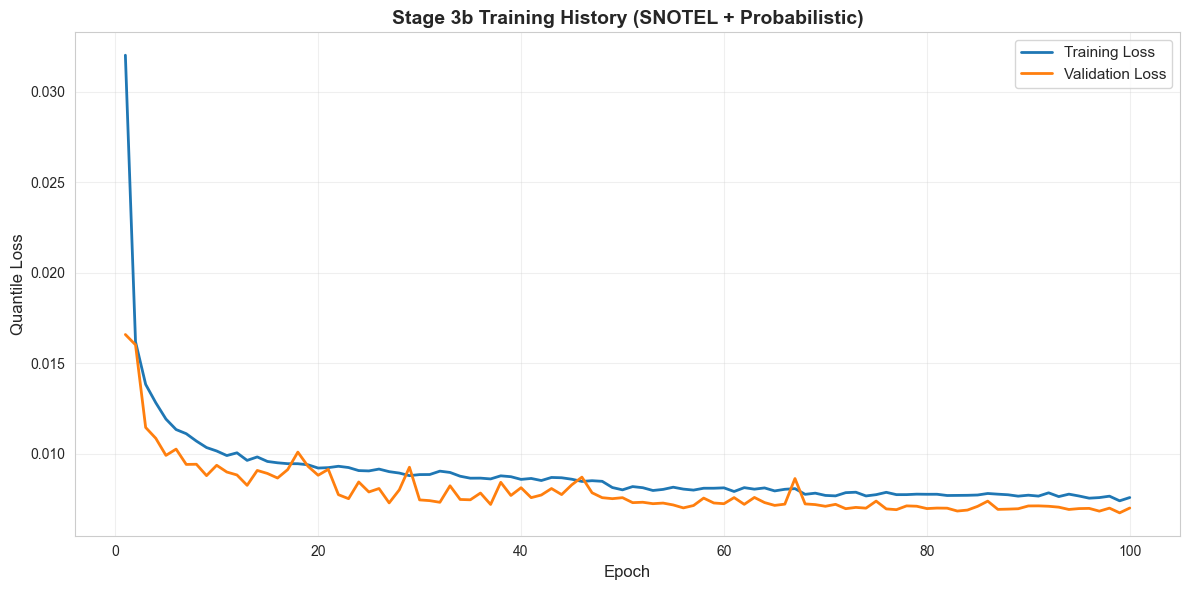

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

epochs_range = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_range, history['train_loss'], label='Training Loss', linewidth=2)
ax.plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Quantile Loss', fontsize=12)
ax.set_title('Stage 3b Training History (SNOTEL + Probabilistic)', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Inference and Probabilistic Evaluation

In [14]:
def predict_dataset(model, dataset, device, batch_size=32):
    """Generate probabilistic predictions."""
    model.eval()
    all_predictions = []
    all_actuals = []
    
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for x_past, x_future, y in loader:
            x_past = x_past.to(device)
            x_future = x_future.to(device)
            outputs = model(x_past, x_future)
            all_predictions.append(outputs.cpu().numpy())
            all_actuals.append(y.cpu().numpy())
    
    return np.vstack(all_predictions), np.vstack(all_actuals)


def inverse_transform_predictions(predictions_scaled, flow_scaler):
    """Inverse transform to cfs."""
    n_samples, horizon, n_quantiles = predictions_scaled.shape
    predictions_cfs = np.zeros_like(predictions_scaled)
    
    for q in range(n_quantiles):
        pred_q = predictions_scaled[:, :, q]
        pred_log = flow_scaler.inverse_transform(pred_q.reshape(-1, 1)).reshape(n_samples, horizon)
        predictions_cfs[:, :, q] = np.exp(pred_log) - 1
    
    return predictions_cfs


# Generate predictions
print("Generating Stage 3b probabilistic predictions...")

val_preds_scaled, val_actuals_scaled = predict_dataset(model, val_dataset, device)
test_preds_scaled, test_actuals_scaled = predict_dataset(model, test_dataset, device)

val_preds_cfs = inverse_transform_predictions(val_preds_scaled, scalers['flow'])
test_preds_cfs = inverse_transform_predictions(test_preds_scaled, scalers['flow'])

# Actuals
val_actuals_log = scalers['flow'].inverse_transform(val_actuals_scaled.reshape(-1, 1)).reshape(val_actuals_scaled.shape)
val_actuals_cfs = np.exp(val_actuals_log) - 1

test_actuals_log = scalers['flow'].inverse_transform(test_actuals_scaled.reshape(-1, 1)).reshape(test_actuals_scaled.shape)
test_actuals_cfs = np.exp(test_actuals_log) - 1

print(f"\nTest predictions shape: {test_preds_cfs.shape} (samples, horizon, quantiles)")
print(f"Test actuals shape: {test_actuals_cfs.shape}")
print(f"\n✓ Predictions generated with [P10, P50, P90] uncertainty bounds!")

Generating Stage 3b probabilistic predictions...

Test predictions shape: (1368, 7, 3) (samples, horizon, quantiles)
Test actuals shape: (1368, 7)

✓ Predictions generated with [P10, P50, P90] uncertainty bounds!


## 14. Probabilistic Evaluation Metrics

In [15]:
def nash_sutcliffe_efficiency(y_true, y_pred):
    """Calculate NSE."""
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (numerator / denominator)


def calculate_probabilistic_metrics(actuals, p10, p50, p90):
    """Calculate comprehensive probabilistic metrics."""
    actuals_flat = actuals.flatten()
    p10_flat = p10.flatten()
    p50_flat = p50.flatten()
    p90_flat = p90.flatten()
    
    # Coverage (PICP)
    in_interval = (actuals_flat >= p10_flat) & (actuals_flat <= p90_flat)
    picp = np.mean(in_interval) * 100
    
    # Interval width (MPIW)
    mpiw = np.mean(p90_flat - p10_flat)
    
    # NSE for P50
    nse = nash_sutcliffe_efficiency(actuals_flat, p50_flat)
    
    # Peak capture (>500 cfs captured by P90)
    high_flow_mask = actuals_flat > 500
    if np.sum(high_flow_mask) > 0:
        peak_capture = np.mean(actuals_flat[high_flow_mask] <= p90_flat[high_flow_mask]) * 100
    else:
        peak_capture = np.nan
    
    # Quantile crossing rate
    crossings = np.sum(p10_flat > p50_flat) + np.sum(p50_flat > p90_flat)
    crossing_rate = crossings / len(actuals_flat) * 100
    
    # Calibration
    p10_calib = np.mean(actuals_flat < p10_flat) * 100
    p50_calib = np.mean(actuals_flat < p50_flat) * 100
    p90_calib = np.mean(actuals_flat < p90_flat) * 100
    
    return {
        'PICP (%)': picp,
        'MPIW (cfs)': mpiw,
        'NSE (P50)': nse,
        'Peak Capture P90 (%)': peak_capture,
        'Crossing Rate (%)': crossing_rate,
        'P10 Calibration (target 10%)': p10_calib,
        'P50 Calibration (target 50%)': p50_calib,
        'P90 Calibration (target 90%)': p90_calib
    }


# Calculate metrics on test set
test_p10 = test_preds_cfs[:, :, 0]
test_p50 = test_preds_cfs[:, :, 1]
test_p90 = test_preds_cfs[:, :, 2]

metrics = calculate_probabilistic_metrics(test_actuals_cfs, test_p10, test_p50, test_p90)

print("\n" + "=" * 80)
print("STAGE 3b PROBABILISTIC EVALUATION METRICS (SNOTEL)")
print("=" * 80)

for key, value in metrics.items():
    if isinstance(value, float):
        print(f"{key:35s}: {value:.4f}")
    else:
        print(f"{key:35s}: {value}")

print("\n" + "=" * 80)
print("SUCCESS CRITERIA:")
print(f"  ✓ Coverage (PICP > 75%):     {metrics['PICP (%)']:.1f}% {'✓' if metrics['PICP (%)'] > 75 else '✗'}")
print(f"  ✓ Peak Capture (P90 > 85%):  {metrics['Peak Capture P90 (%)']:.1f}% {'✓' if metrics['Peak Capture P90 (%)'] > 85 else '✗'}")
print(f"  ✓ No Crossing (0%):          {metrics['Crossing Rate (%)']:.2f}% {'✓' if metrics['Crossing Rate (%)'] == 0 else '✗'}")
print("=" * 80)


STAGE 3b PROBABILISTIC EVALUATION METRICS (SNOTEL)
PICP (%)                           : 81.8191
MPIW (cfs)                         : 866.2125854492188
NSE (P50)                          : 0.861141562461853
Peak Capture P90 (%)               : 96.8711
Crossing Rate (%)                  : 0.0000
P10 Calibration (target 10%)       : 10.2026
P50 Calibration (target 50%)       : 58.6884
P90 Calibration (target 90%)       : 92.0217

SUCCESS CRITERIA:
  ✓ Coverage (PICP > 75%):     81.8% ✓
  ✓ Peak Capture (P90 > 85%):  96.9% ✓
  ✓ No Crossing (0%):          0.00% ✓


## 15. Fan Chart Visualization

Generating Fan Charts...

Plotting - Spring 2022...


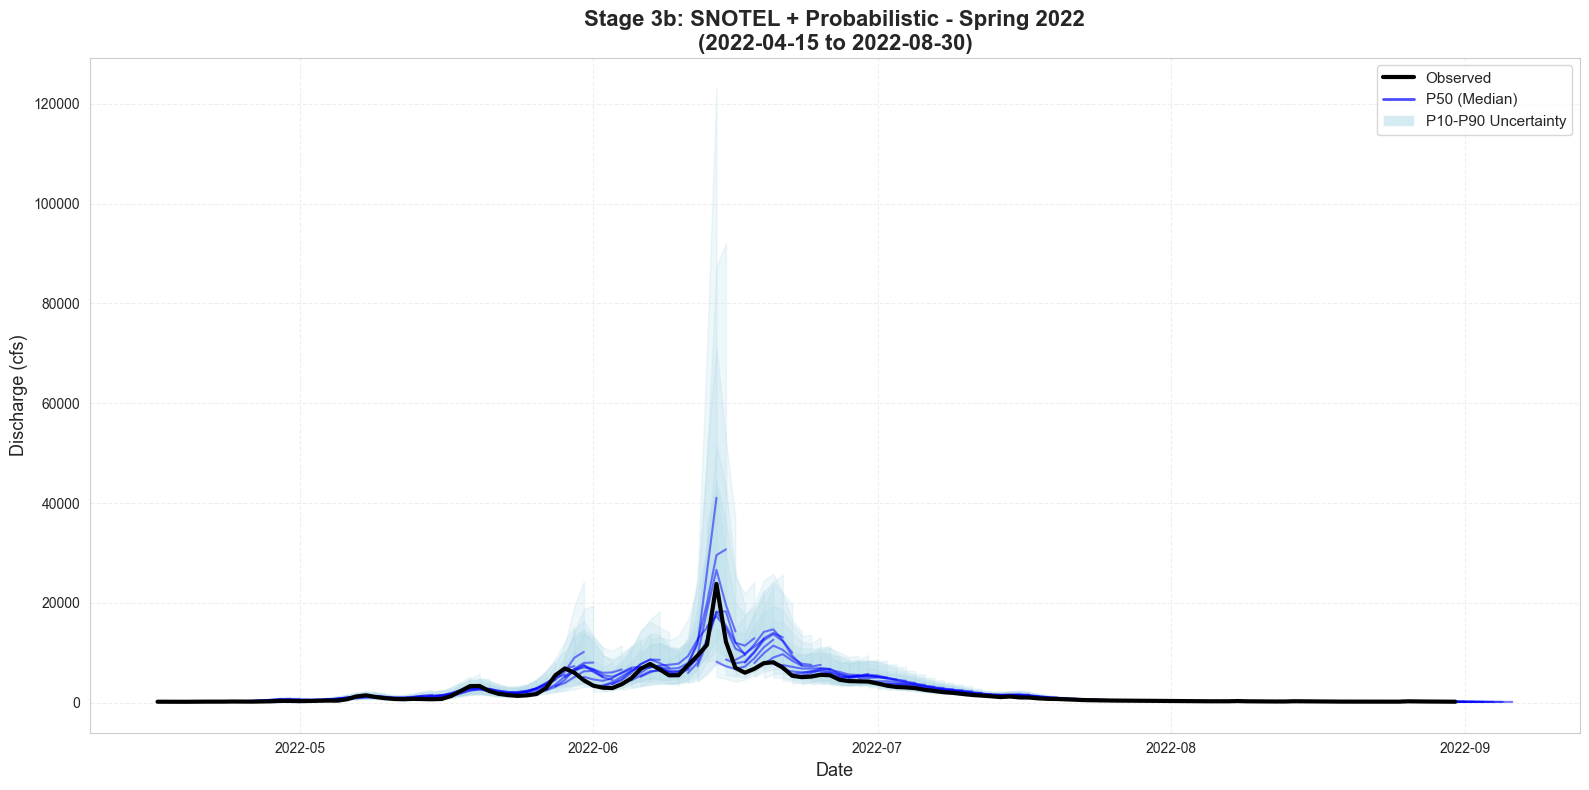

Plotting - Spring 2023...


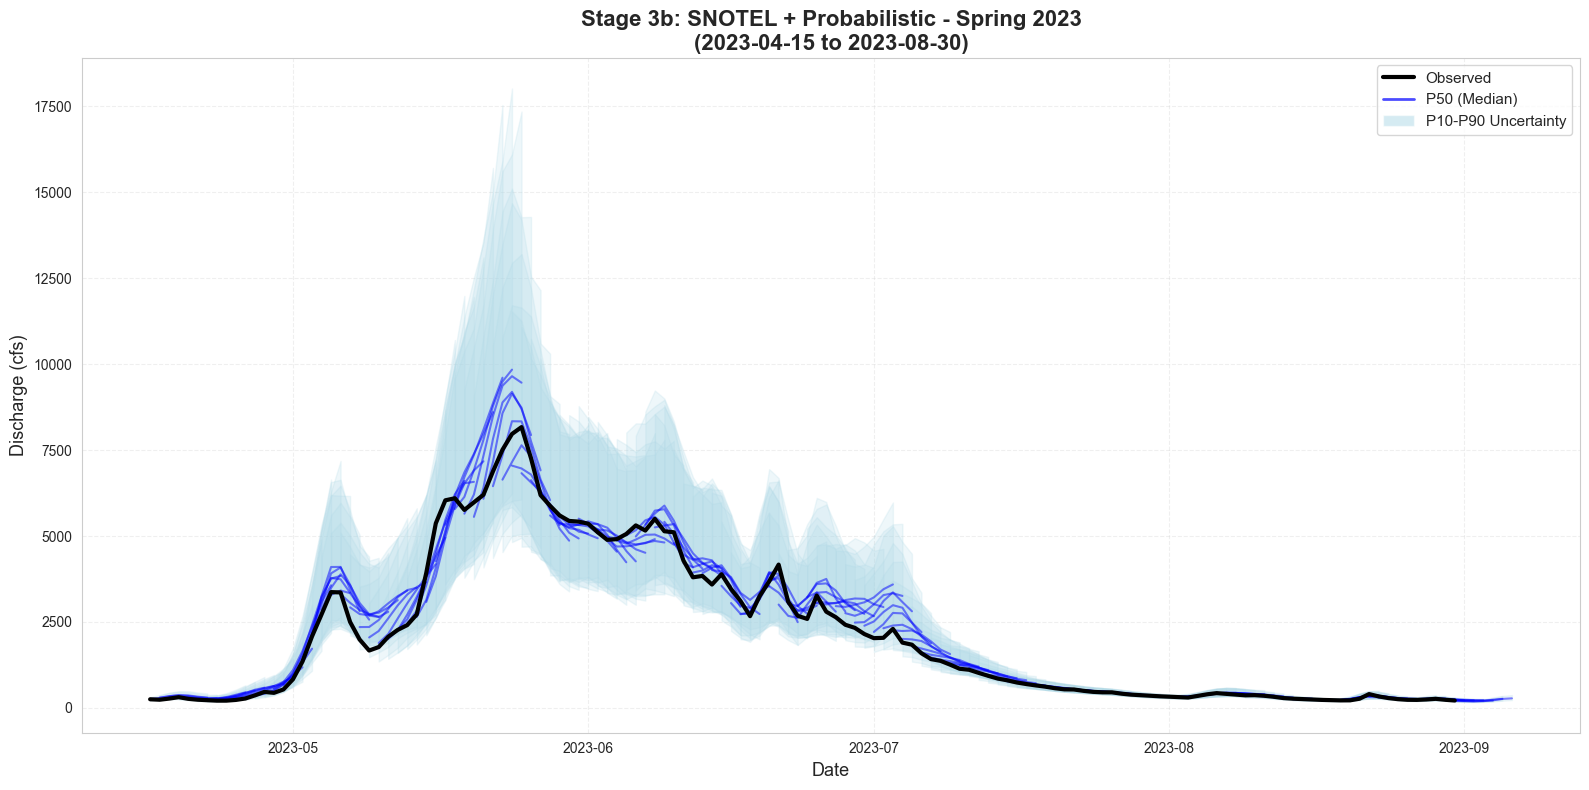

Plotting - Spring 2024...


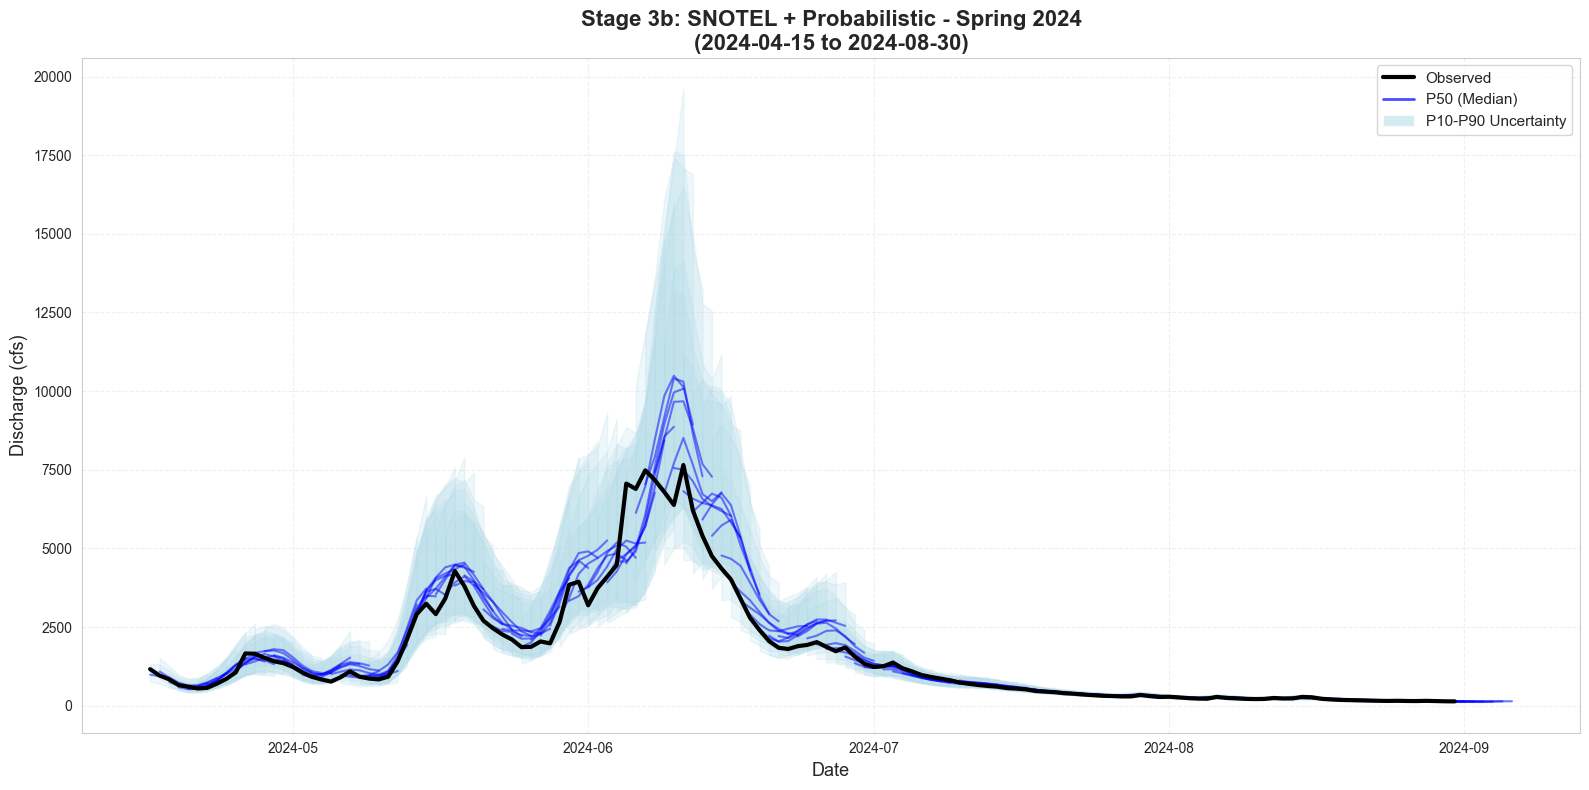

In [16]:
# Get prediction dates
val_start_idx = len(train_df) + LOOKBACK
test_start_idx = len(train_df) + len(val_df) + LOOKBACK

val_prediction_dates = df['date'].iloc[val_start_idx:val_start_idx + len(val_preds_cfs)].values
test_prediction_dates = df['date'].iloc[test_start_idx:test_start_idx + len(test_preds_cfs)].values

all_prediction_dates = np.concatenate([val_prediction_dates, test_prediction_dates])
all_preds_cfs = np.vstack([val_preds_cfs, test_preds_cfs])
all_actuals_cfs = np.vstack([val_actuals_cfs, test_actuals_cfs])

all_prediction_dates_pd = pd.to_datetime(all_prediction_dates)


def plot_fan_chart(dates, actuals, p10, p50, p90, start_date, end_date, title_suffix=""):
    """Plot fan chart with P10-P90 uncertainty band."""
    mask = (dates >= start_date) & (dates <= end_date)
    subset_dates = dates[mask]
    subset_actuals = actuals[mask, 0]
    subset_p10 = p10[mask]
    subset_p50 = p50[mask]
    subset_p90 = p90[mask]
    
    if len(subset_dates) == 0:
        print(f"⚠️  No data for {start_date} to {end_date}")
        return
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    valid_dates = subset_dates + pd.Timedelta(days=1)
    ax.plot(valid_dates, subset_actuals, color='black', linewidth=3, 
            label='Observed Flow', zorder=10)
    
    for i in range(len(subset_dates)):
        launch_date = subset_dates[i]
        strand_dates = [launch_date + pd.Timedelta(days=d+1) for d in range(7)]
        
        ax.plot(strand_dates, subset_p50[i], color='blue', alpha=0.5, 
               linewidth=1.5, zorder=5)
        ax.fill_between(strand_dates, subset_p10[i], subset_p90[i],
                        color='lightblue', alpha=0.2, zorder=3)
    
    ax.set_title(f'Stage 3b: SNOTEL + Probabilistic {title_suffix}\n({start_date} to {end_date})', 
                fontsize=16, fontweight='bold')
    ax.set_ylabel('Discharge (cfs)', fontsize=13)
    ax.set_xlabel('Date', fontsize=13)
    
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    custom_elements = [
        Line2D([0], [0], color='black', lw=3),
        Line2D([0], [0], color='blue', lw=2, alpha=0.7),
        Patch(facecolor='lightblue', alpha=0.5)
    ]
    ax.legend(custom_elements, ['Observed', 'P50 (Median)', 'P10-P90 Uncertainty'], 
             fontsize=11)
    
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


# Plot multiple periods
date_ranges = [
    ('2022-04-15', '2022-08-30', '- Spring 2022'),
    ('2023-04-15', '2023-08-30', '- Spring 2023'),
    ('2024-04-15', '2024-08-30', '- Spring 2024'),
]

print("Generating Fan Charts...\n")
for start_date, end_date, label in date_ranges:
    print(f"Plotting {label}...")
    plot_fan_chart(
        dates=all_prediction_dates_pd,
        actuals=all_actuals_cfs,
        p10=all_preds_cfs[:, :, 0],
        p50=all_preds_cfs[:, :, 1],
        p90=all_preds_cfs[:, :, 2],
        start_date=start_date,
        end_date=end_date,
        title_suffix=label
    )

## 16. Save Model and Metadata

In [17]:
import json
from datetime import datetime

# Save model
torch.save(model.state_dict(), '../best_stage3b_snotel_model.pth')

# Save metadata
metadata = {
    'model_type': 'ProbabilisticLSTM with SNOTEL',
    'stage': '3b',
    'variant': 'snotel_probabilistic',
    'data_source': 'daily_streamflow',
    'quantiles': [0.1, 0.5, 0.9],
    'architecture': {
        'type': 'Simple LSTM with quantile output',
        'input_dim': n_history_features,
        'future_dim': n_future_features,
        'hidden_size': 64,
        'num_layers': 2,
        'dropout': 0.2,
        'lookback': LOOKBACK,
        'horizon': HORIZON,
        'output_shape': '(batch, 7, 3)'
    },
    'features': {
        'endogenous': ['log_flow'],
        'seasonal': ['sin_doy', 'cos_doy'],
        'climate': climate_features,
        'snotel': swe_features
    },
    'training': {
        'epochs': len(history['train_loss']),
        'batch_size': BATCH_SIZE,
        'learning_rate': 0.001,
        'loss_function': 'quantile_loss',
        'optimizer': 'Adam',
        'best_val_loss': float(best_val_loss)
    },
    'performance': {
        'picp': float(metrics['PICP (%)']),
        'mpiw': float(metrics['MPIW (cfs)']),
        'nse_p50': float(metrics['NSE (P50)']),
        'peak_capture_p90': float(metrics['Peak Capture P90 (%)']),
        'crossing_rate': float(metrics['Crossing Rate (%)'])
    },
    'calibration': {
        'p10': {'target': 10, 'actual': float(metrics['P10 Calibration (target 10%)'])},
        'p50': {'target': 50, 'actual': float(metrics['P50 Calibration (target 50%)'])},
        'p90': {'target': 90, 'actual': float(metrics['P90 Calibration (target 90%)'])}
    },
    'status': 'Stage 3b - SNOTEL + Probabilistic (Simple LSTM)',
    'timestamp': datetime.now().isoformat()
}

with open('../stage3b_snotel_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model and metadata saved!")
print(f"  Model: ../best_stage3b_snotel_model.pth")
print(f"  Metadata: ../stage3b_snotel_metadata.json")

Model and metadata saved!
  Model: ../best_stage3b_snotel_model.pth
  Metadata: ../stage3b_snotel_metadata.json


## 17. Summary

### Stage 3b (SNOTEL + Probabilistic) Implementation Complete

#### Architecture: Simple LSTM with Quantile Output

Same architecture as Stage 3, but outputs 3 quantiles instead of point forecast:

```
Input (x_past):  60 days × 11 features (flow, sin/cos, climate, SWE)
Input (x_future): 7 days × 6 features (climate only)
      ↓
LSTM Encoder (2 layers, 64 hidden)
      ↓
Concatenate [last_hidden, flattened_future]
      ↓
FC Layers (128 → 21)
      ↓
Reshape to (7, 3)
      ↓
Output: 7 days × [P10, P50, P90]
```

#### Key Features

**From Stage 3 (SNOTEL)**:
- Snow Water Equivalent from SNOTEL stations
- Parker Peak (683) and Northeast Entrance (670)
- Explicit storage state for snowmelt prediction
- Simple LSTM architecture (no seq2seq complexity)

**New in Stage 3b**:
- Quantile regression [P10, P50, P90]
- Uncertainty quantification for each forecast day
- Pinball/quantile loss function

#### Comparison: Stage 3 vs Stage 3b

| Feature | Stage 3 (SNOTEL) | Stage 3b (SNOTEL + Prob) |
|---------|------------------|-------------------------|
| Output | Point forecast (7,) | Quantiles (7, 3) |
| Architecture | LSTM → Linear | LSTM → Linear |
| Loss | MSE | Quantile/Pinball |
| Uncertainty | None | [P10, P50, P90] |

#### Advantages

1. **Same simplicity**: No seq2seq encoder-decoder complexity
2. **Storage state**: SWE prevents over-prediction when snow depletes
3. **Uncertainty bounds**: Know when forecasts are reliable
4. **Peak capture**: P90 catches extreme events
5. **Fewer parameters**: Simpler model, faster training